# 01 · Atmosphere

Demonstration of the **US Standard Atmosphere 1976** model implemented in `reentrykit.atmosphere`. This notebook computes atmospheric properties across the full 0–86 km valid range and plots the four primary quantities: temperature, pressure, density, and speed of sound.

**Reference:** NOAA/NASA/USAF (1976). *U.S. Standard Atmosphere, 1976*. NASA-TM-X-74335.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from reentrykit.atmosphere import us1976, MAX_ALTITUDE

In [2]:
# Sample the atmosphere on a dense grid
altitudes = np.linspace(0.0, MAX_ALTITUDE, 500)

# Compute atmosphere state at each altitude
states = [us1976(h) for h in altitudes]

# Extract each quantity as a NumPy array for plotting
temperatures = np.array([s.temperature for s in states])
pressures = np.array([s.pressure for s in states])
densities = np.array([s.density for s in states])
speeds_of_sound = np.array([s.speed_of_sound for s in states])

print(f"Sampled {len(altitudes)} altitudes from 0 to {MAX_ALTITUDE/1000:.0f} km")
print(f"T range: {temperatures.min():.1f} to {temperatures.max():.1f} K")
print(f"p range: {pressures.min():.3f} to {pressures.max():.0f} Pa")

Sampled 500 altitudes from 0 to 86 km
T range: 184.7 to 288.1 K
p range: 0.302 to 101325 Pa


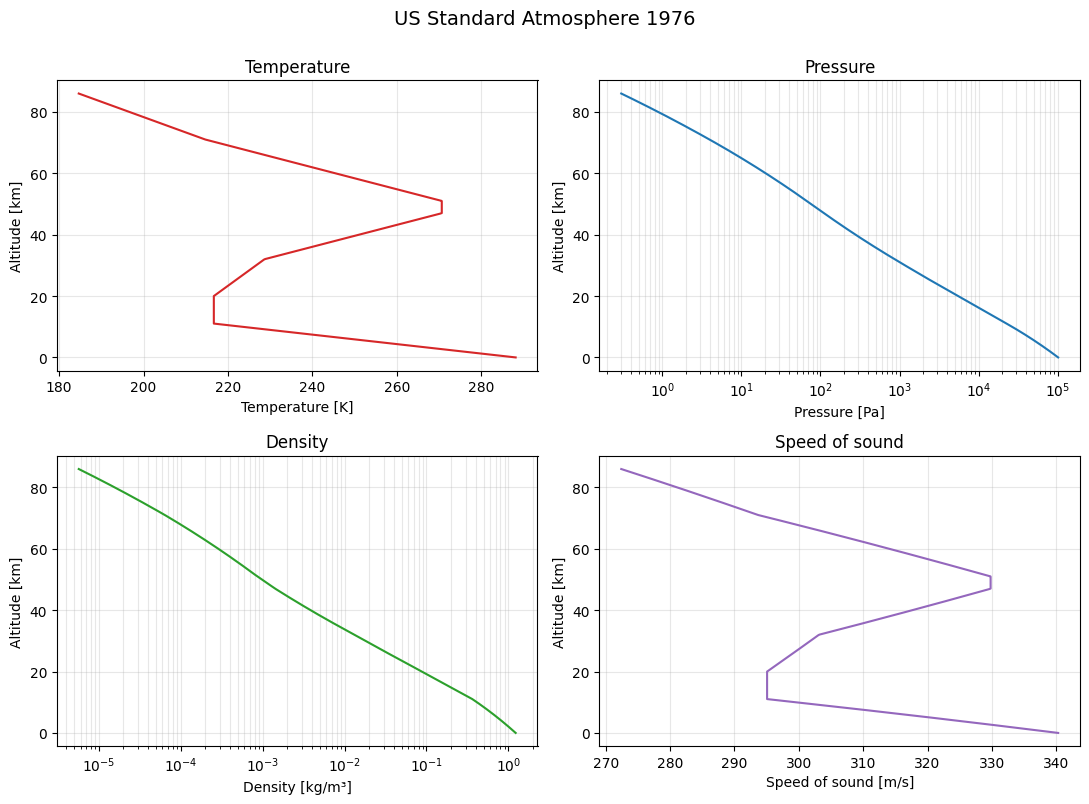

In [3]:
# Convert altitude from meters to kilometers for readability
altitudes_km = altitudes / 1000.0

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# Top-left: temperature
ax = axes[0, 0]
ax.plot(temperatures, altitudes_km, color="tab:red", linewidth=1.5)
ax.set_xlabel("Temperature [K]")
ax.set_ylabel("Altitude [km]")
ax.set_title("Temperature")
ax.grid(True, alpha=0.3)

# Top-right: pressure (log scale)
ax = axes[0, 1]
ax.plot(pressures, altitudes_km, color="tab:blue", linewidth=1.5)
ax.set_xscale("log")
ax.set_xlabel("Pressure [Pa]")
ax.set_ylabel("Altitude [km]")
ax.set_title("Pressure")
ax.grid(True, which="both", alpha=0.3)

# Bottom-left: density (log scale)
ax = axes[1, 0]
ax.plot(densities, altitudes_km, color="tab:green", linewidth=1.5)
ax.set_xscale("log")
ax.set_xlabel("Density [kg/m³]")
ax.set_ylabel("Altitude [km]")
ax.set_title("Density")
ax.grid(True, which="both", alpha=0.3)

# Bottom-right: speed of sound
ax = axes[1, 1]
ax.plot(speeds_of_sound, altitudes_km, color="tab:purple", linewidth=1.5)
ax.set_xlabel("Speed of sound [m/s]")
ax.set_ylabel("Altitude [km]")
ax.set_title("Speed of sound")
ax.grid(True, alpha=0.3)

fig.suptitle("US Standard Atmosphere 1976", fontsize=14, y=1.00)
fig.tight_layout()
plt.show()

## Observations

The four panels show the characteristic structure of Earth's atmosphere up to the mesopause at 86 km:

- **Temperature** exhibits the classic non-monotonic profile: cooling through the troposphere (0–11 km), isothermal through the lower stratosphere (11–20 km), warming through the ozone-heated stratosphere (20–47 km), and cooling again through the mesosphere (51–86 km). The local maximum near 47 km — the *stratopause* — reaches 270.65 K.

- **Pressure** decays monotonically by more than five orders of magnitude, from 101,325 Pa at sea level to roughly 0.3 Pa at 86 km. On the log scale the profile is nearly linear, confirming the exponential decay predicted by hydrostatic equilibrium in a constant-gravity atmosphere.

- **Density** follows a similar exponential decay, from 1.225 kg/m³ at sea level to about 6×10⁻⁶ kg/m³ at 86 km. The curvature visible in the density profile (relative to the pressure profile) reflects the coupling through temperature in the ideal gas law.

- **Speed of sound** tracks the temperature profile directly because *a = √(γ R T / M)*. Values range from 340 m/s at sea level to about 275 m/s at the mesopause.

These are the boundary conditions every downstream analysis in this project will depend on: trajectory simulation, aerothermal heating, and atmospheric loads all consume atmosphere properties returned by `us1976(altitude)`.

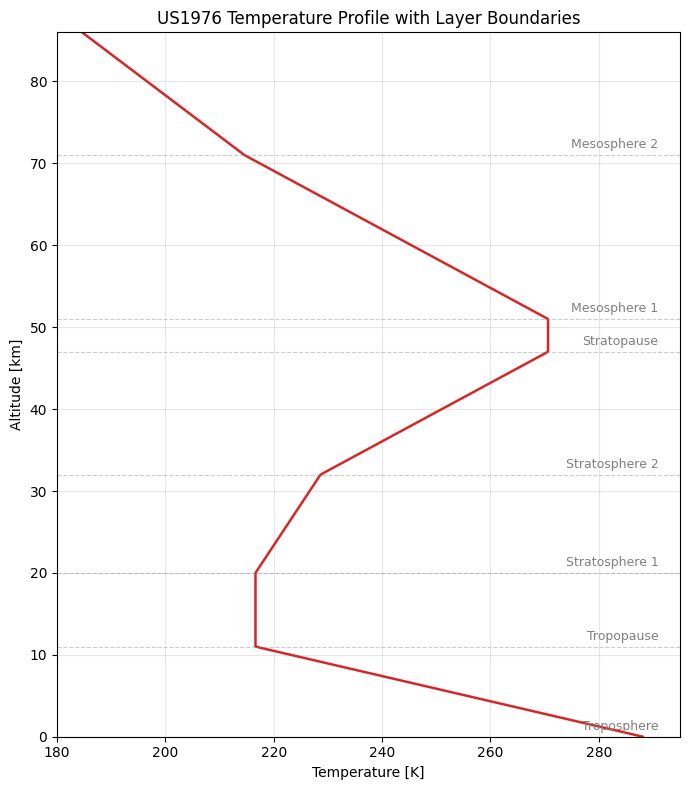

In [4]:
from reentrykit.atmosphere import _LAYER_BASE_ALTITUDES

fig, ax = plt.subplots(figsize=(7, 8))

ax.plot(temperatures, altitudes_km, color="tab:red", linewidth=1.8, label="US1976")

# Annotate the layer boundaries
layer_names = ["Troposphere", "Tropopause", "Stratosphere 1", "Stratosphere 2",
               "Stratopause", "Mesosphere 1", "Mesosphere 2"]

for h_base, name in zip(_LAYER_BASE_ALTITUDES, layer_names):
    ax.axhline(h_base / 1000.0, color="gray", linestyle="--", alpha=0.4, linewidth=0.8)
    ax.text(291, h_base / 1000.0 + 0.5, name, fontsize=9, color="gray",
            verticalalignment="bottom", horizontalalignment="right")

ax.set_xlabel("Temperature [K]")
ax.set_ylabel("Altitude [km]")
ax.set_title("US1976 Temperature Profile with Layer Boundaries")
ax.grid(True, alpha=0.3)
ax.set_xlim(180, 295)
ax.set_ylim(0, 86)

plt.tight_layout()
plt.show()